In [1]:
#Imports
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-01-18 16:18:41.213188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768753121.239580    3736 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768753121.247360    3736 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768753121.268702    3736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768753121.268748    3736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768753121.268751    3736 computation_placer.cc:177] computation placer alr

In [2]:
#data Path
base_path = '/kaggle/input/gtsrb-german-traffic-sign' 
train_path = os.path.join(base_path, 'Train')
img_height = 30
img_width = 30
channels = 3
num_classes = 43 

In [4]:
#Data Augmentation
def add_custom_noise(image):
    # Convert image to float32 for processing
    image = tf.image.convert_image_dtype(image, tf.float32) / 255.0
    if np.random.rand() > 0.3:
        return image
    # Randomly choose which noise type to apply
    choice = np.random.randint(0, 3) 
    
    if choice == 0:
        # Simulate Noise
        noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.03, dtype=tf.float32)
        image = tf.add(image, noise)
    elif choice == 1:
        # Simulate Lighting changes
        image = tf.image.random_brightness(image, max_delta=0.1)
    elif choice == 2:
        # Simulating Low Contrast
        image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
        
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

In [7]:
# Data Generators
# Initialize Data Generator with validation split
datagenerate = ImageDataGenerator(
preprocessing_function=add_custom_noise,   
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2)

test_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2)

# Load Training Data
train_generator = datagenerate.flow_from_directory(train_path,
target_size=(img_height, img_width),batch_size=32,
class_mode='categorical',subset='training', seed=42)

# Load Validation Data
valid_generator = datagenerate.flow_from_directory(train_path,
target_size=(img_height, img_width),batch_size=32,
class_mode='categorical',subset='validation', seed=42)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [15]:
#CNN Model
model = Sequential([
    # Identification Basic lines and edges
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, channels)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    # Identification Shapes
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    # Deep processing
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    # Classification
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
# Training
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
patience=2, 
verbose=1, 
factor=0.5, 
min_lr=0.00001)

epochs = 15
history = model.fit(train_generator,
validation_data=valid_generator,epochs=epochs,
callbacks=[learning_rate_reduction])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 128s 127ms/step - accuracy: 0.3417 - loss: 2.5077 - val_accuracy: 0.7086 - val_loss: 1.0785 - learning_rate: 0.0010
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 124s 127ms/step - accuracy: 0.7810 - loss: 0.6622 - val_accuracy: 0.8120 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 122s 125ms/step - accuracy: 0.8720 - loss: 0.3931 - val_accuracy: 0.8507 - val_loss: 0.5379 - learning_rate: 0.0010
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 124s 126ms/step - accuracy: 0.9026 - loss: 0.2977 - val_accuracy: 0.8612 - val_loss: 0.5182 - learning_rate: 0.0010
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 125s 128ms/step - accuracy: 0.9227 - loss: 0.2441 - val_accuracy: 0.8498 - val_loss: 0.6174 - learning_rate: 0.0010
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9251 - loss: 0.2362
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
981/981 ━━━━━━━━━━━━━━━━━━━━ 123s 125ms/step - accuracy:

In [12]:
#clean Data Generator

clean_generator = test_datagen.flow_from_directory(
    train_path,
    target_size=(img_height, img_width),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)
score = model.evaluate(clean_generator)
print(f"Final Test Accuracy: {score[1]*100:.2f}%")

Found 7841 images belonging to 43 classes.
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.9675 - loss: 0.1336
Final Test Accuracy: 95.65%


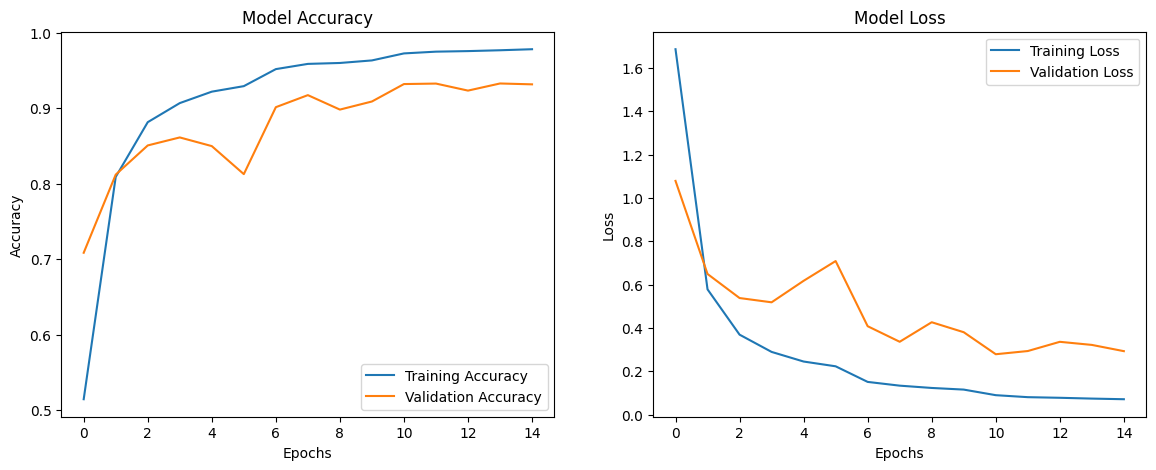

In [13]:
#Results 
# Accuracy graph
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Error graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


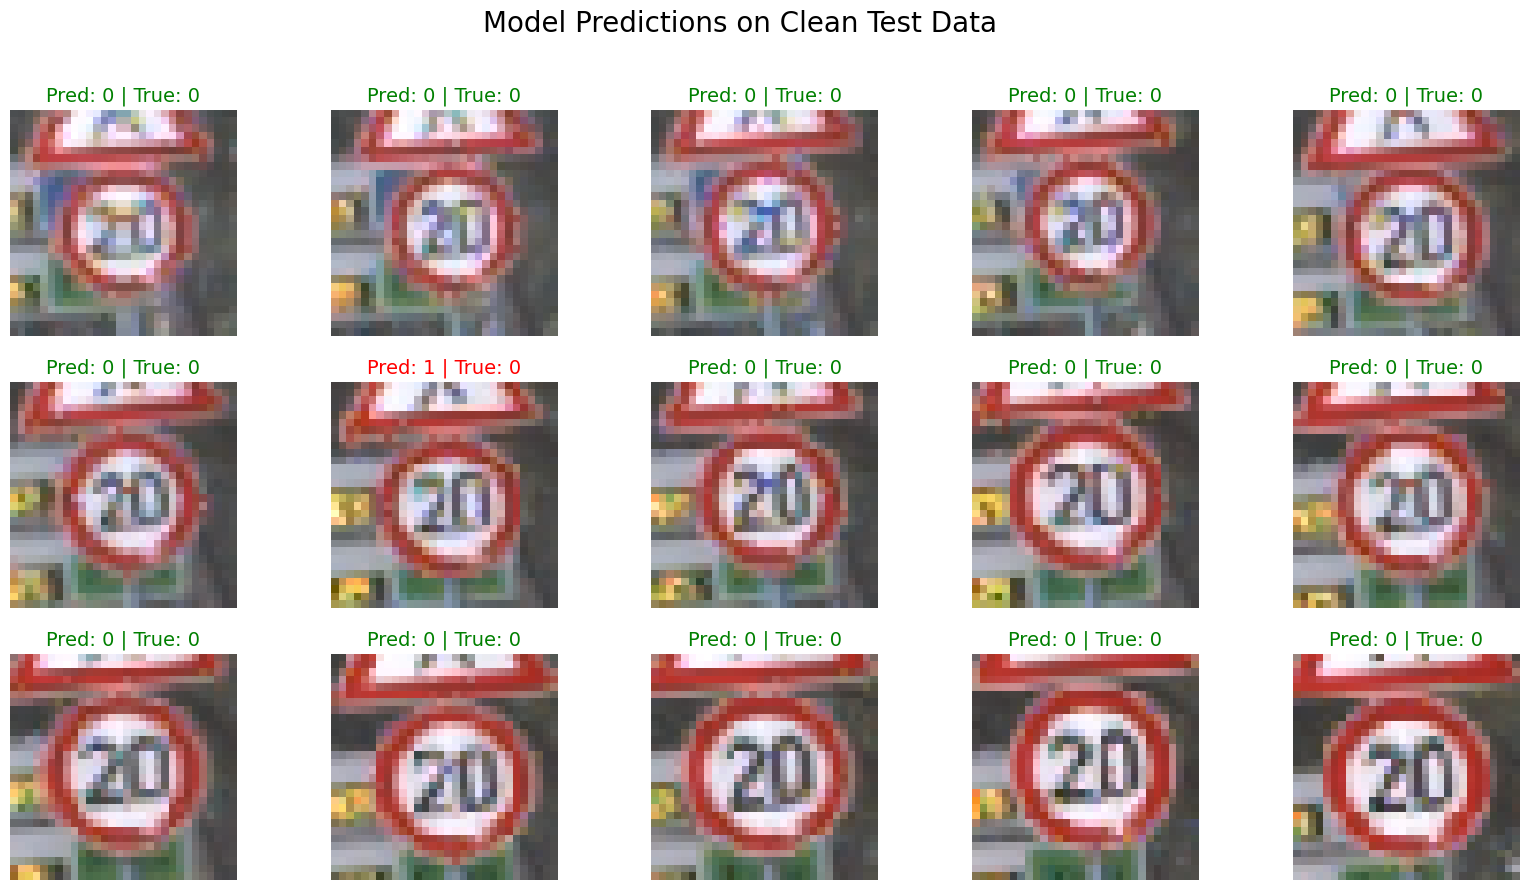

Model saved successfully as 'traffic_sign_model_95acc.h5'


In [14]:
# Visualizing Predictions 
x_test, y_test = next(clean_generator)
# Make predictions
predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

#  Plot for 15 images
plt.figure(figsize=(20, 10))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i])
    
 # Check if prediction is correct
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'  
    plt.title(f"Pred: {pred_labels[i]} | True: {true_labels[i]}", color=color, fontsize=14)
    plt.axis('off')
plt.suptitle("Model Predictions on Clean Test Data", fontsize=20)
plt.show()
model.save('traffic_sign_model_95acc.h5')
print("Model saved successfully as 'traffic_sign_model_95acc.h5'")